<a href="https://colab.research.google.com/github/Himel738/AI-ML-Playground/blob/main/Week-4/Copy_of_AI_Programming_With_Python_Final_Exam_Question.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# AI Programming with Python Final Exam

**Name: Shohanur Rahman Shohan**

**Course Email:**  sohanurhimel@gmail.com


## End of Assignment

Before submitting:
- Must watch the Exam Instructions Video
- Run all cells from top to bottom.  
- Check that all answer sections are filled.  
- Instruction video অনুযায়ী আমাদের দেয়া Colab ফাইলটি থেকে প্রথম একটি Save copy in drive করে নিবা। এরপর Google colab এর মধ্যে কোডগুলো করবে এবং সেই ফাইলটি ‘Anyone with the link’ & ‘View’ Access দিয়ে ফাইলটির Shareble Link টি সাবমিট করবে।

# 0) Starter Code (Run First)

In [1]:
# You must run this code and use this dataset for all questions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
num_students = 50

# Student data
student_ids = np.arange(201, 201 + num_students)
student_ages = np.random.randint(15, 22, num_students)
student_scores = np.random.randint(40, 100, num_students)
student_attendance = np.random.randint(60, 100, num_students)  # percentage

departments_list = [
    "Science",
    "Commerce",
    "Arts",
    "Computer Science",
    "Mathematics",
    "English",
    "Physics",
    "Chemistry",
    "Biology",
    "Economics"
]

student_departments = np.random.choice(departments_list, num_students)

grade_conditions = [
    student_scores >= 80,
    (student_scores >= 65) & (student_scores < 80),
    (student_scores >= 50) & (student_scores < 65),
    student_scores < 50
]
grade_values = ["A", "B", "C", "F"]
student_grades = np.select(grade_conditions, grade_values, default="F")

# Create DataFrame
data = pd.DataFrame({
    "student_id": student_ids,
    "student_age": student_ages,
    "score": student_scores,
    "attendance": student_attendance,
    "department": student_departments,
    "grade": student_grades
})

# Save dataset
data.to_csv("school_data.csv", index=False)

# Question 01: [ Marks 10 ]

Use NumPy arrays from the score and attendance columns. Print both arrays and display:

* Data type
* Number of dimensions
* Shape
* Total number of elements

# Write Answer 01:


In [4]:
score = np.array(data['score'])
attendance = np.array(data['attendance'])
# Data Type
print(type(score))
print(type(attendance))

# Number of Dimension
print(score.ndim)
print(attendance.ndim)

# shape
print(score.shape)
print(attendance.shape)

# Total Element
print(len(score))
print(len(attendance))


<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
1
1
(50,)
(50,)
50
50


# Question 02: [ Marks 10 ]

## Using NumPy functions on :

* Find the maximum and minimum score
* Calculate the average score
* Calculate the average attendance

Then, extract students who:

* Have a score greater than the average score

Print:

* The filtered score array

## Write Answer 02:


In [7]:
max_score = np.max(score)
min_score = np.min(score)
# MAx and Min
print(max_score, min_score)

# Average Score
print(np.average(score))

# Average attendance
print(np.average(attendance))

filter_score_array = np.where(score > np.average(score))
print(filter_score_array)

99 41
67.3
79.58
(array([ 0,  1,  5,  9, 11, 12, 15, 19, 20, 22, 24, 25, 28, 29, 30, 34, 35,
       37, 38, 41, 42, 44, 46, 47]),)


# Question 03: [Marks 10]

##
Load the school_data.csv file into a Pandas DataFrame.

* Display the first 3 rows
* Show dataset information using .info()
* Display summary statistics using .describe()

Then filter the dataset to include only:

* student_id, student_age, department, grade

Select students whose age is between 16 and 20, sort them by student_id, and display the last 3 rows of the result.


## Write Answer 03:

In [24]:
student_data = pd.read_csv('school_data.csv')
print(student_data.head(3))
print(student_data.info())
print(student_data.describe())
# Modified
filter_student_data = student_data.loc[
    (student_data['student_age'] >= 16) &
    (student_data['student_age'] <= 20)
][['student_id','student_age','department','grade']]
filter_student_data.tail(3)


   student_id  student_age  score  attendance department grade
0         201           21     76          73    Physics     B
1         202           18     90          82    Physics     A
2         203           19     46          99    Biology     F
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   student_id   50 non-null     int64 
 1   student_age  50 non-null     int64 
 2   score        50 non-null     int64 
 3   attendance   50 non-null     int64 
 4   department   50 non-null     object
 5   grade        50 non-null     object
dtypes: int64(4), object(2)
memory usage: 2.5+ KB
None
       student_id  student_age      score  attendance
count    50.00000    50.000000  50.000000   50.000000
mean    225.50000    18.280000  67.300000   79.580000
std      14.57738     1.852081  18.248008   12.163998
min     201.00000    15.000000  41.000000   60.

,student_id,student_age,department,grade
45,246,18,Biology,C
47,248,18,Science,A
49,250,17,Economics,F



# Question 04: [ Marks 10 ]

##
Using .loc:

* Increase the score by 10% for students in "Computer Science" and "Mathematics" departments
* Increase the score by 5% for all other departments
* Cap the score at 100 (no score should exceed 100 after the raise)

Then print a DataFrame that includes:

* student_id, department, previous_score, new_score, score_increase


## Write Answer 04:

In [23]:
student_data['previous_score'] = student_data['score']
student_data['new_score'] = student_data['score']

student_data.loc[
    student_data['department'].str.contains(
        'Computer Science|Mathematics'
    ),'new_score'
] = student_data['new_score'] * 1.10

modified_student_data = student_data.loc[
    ~student_data['department'].str.contains(
        'Computer Science|Mathematics'
    ),'new_score'
] = student_data['new_score'] * 1.10

student_data['new_score'] = student_data['new_score'].clip(upper = 100)

student_data['score_increase'] = student_data['new_score'] - student_data['previous_score']

student_data

,student_id,student_age,score,attendance,department,grade,previous_score,new_score,score_increase
0,201,21,83.6,73,Physics,B,83.6,91.96,8.36
1,202,18,99.0,82,Physics,A,99.0,100.00,1.00
2,203,19,50.6,99,Biology,F,50.6,55.66,5.06
3,204,21,66.0,80,Economics,C,66.0,72.60,6.60
4,205,17,52.8,75,Economics,F,52.8,58.08,5.28
5,206,19,85.8,77,Arts,B,85.8,94.38,8.58
6,207,19,62.7,83,Physics,C,62.7,68.97,6.27
7,208,21,47.3,85,Science,F,47.3,52.03,4.73
8,209,16,70.4,84,Computer Science,C,70.4,77.44,7.04
9,210,17,108.9,88,Computer Science,A,108.9,100.00,-8.90


# Question 05: [ Marks 10 ]

Using Matplotlib, create a bar chart that shows the average score per department.

* X-axis: Department names
* Y-axis: Average score
* Add a title: "Average Score by Department"
* Display the chart

## Answer 05:

department
Arts                70.000000
Biology             70.125000
Chemistry           63.666667
Commerce            59.000000
Computer Science    67.833333
Economics           58.666667
English             54.250000
Mathematics         73.333333
Physics             78.444444
Science             62.000000
Name: score, dtype: float64


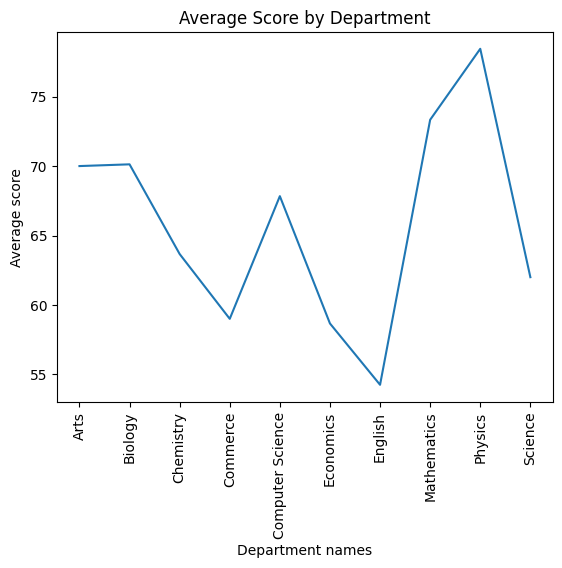

In [39]:
avearge_score = student_data.groupby('department')['score'].mean()
print(avearge_score)

plt.xlabel("Department names")
plt.ylabel("Average score")
plt.title("Average Score by Department")
plt.plot(avearge_score.index,avearge_score.values)
plt.xticks(rotation=90)
plt.show()

# Question 06: [ Marks 10 ]

Using Matplotlib, create a histogram of the score column.

* Use 10 bins
* Add a title: "Distribution of Student Scores"
* Label X-axis as "Score" and Y-axis as "Number of Students"
* Display the chart

## Answer 06:

(array([8., 5., 7., 3., 4., 5., 4., 5., 6., 3.]),
 array([41. , 46.8, 52.6, 58.4, 64.2, 70. , 75.8, 81.6, 87.4, 93.2, 99. ]),
 <BarContainer object of 10 artists>)

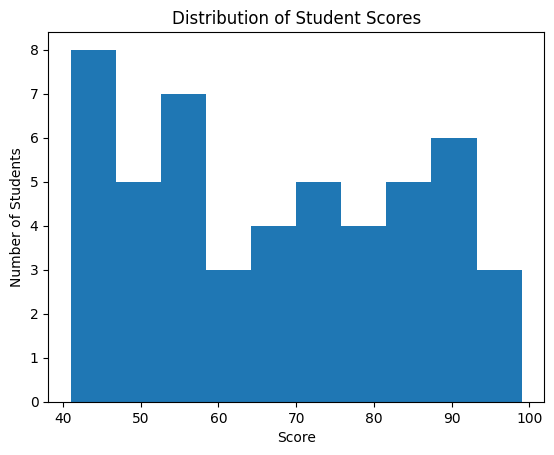

In [38]:
plt.xlabel("Score")
plt.ylabel("Number of Students")
plt.title("Distribution of Student Scores")
plt.hist(student_data['score'],bins=10)

# Question 07: [ Marks 10 ]

Using Matplotlib, create a scatter plot to visualize the relationship between attendance and score.

* X-axis: Attendance (%)
* Y-axis: Score
* Add a title: "Attendance vs Score"
* Label both axes properly
* Display the chart

## Answer 07:


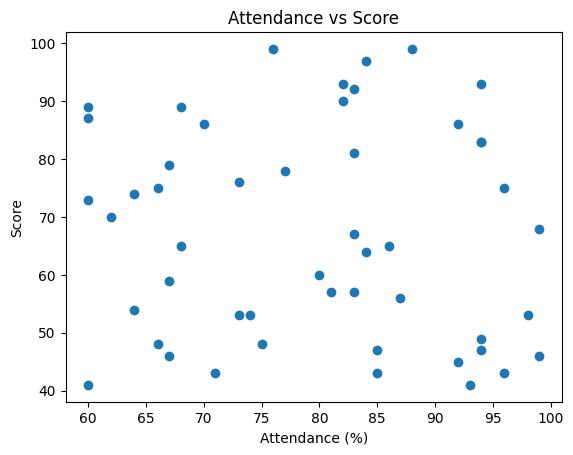

In [41]:
plt.xlabel("Attendance (%)")
plt.ylabel("Score")
plt.title("Attendance vs Score")
plt.scatter(student_data['attendance'],student_data['score'])

# Question 08: [ Marks 10 ]

Using Seaborn, create a boxplot / barplot that shows the distribution of score across different grade categories.

* X-axis: Grade
* Y-axis: Score
* Add a title: "Score Distribution by Grade"
* Display the chart

## Answer 08:

<Axes: xlabel='grade', ylabel='score'>

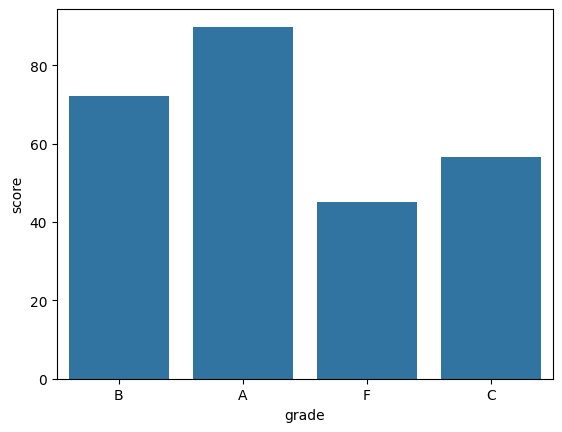

In [46]:


sns.barplot(data=student_data,x="grade",y="score",errorbar=None)



# Question 09: [ Marks 10 ]

Using Seaborn, create a countplot showing the number of students in each department.

* Add a title: "Number of Students per Department"
* Display the chart

# Write Answer 09:

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Physics'),
  Text(1, 0, 'Biology'),
  Text(2, 0, 'Economics'),
  Text(3, 0, 'Arts'),
  Text(4, 0, 'Science'),
  Text(5, 0, 'Computer Science'),
  Text(6, 0, 'Mathematics'),
  Text(7, 0, 'English'),
  Text(8, 0, 'Commerce'),
  Text(9, 0, 'Chemistry')])

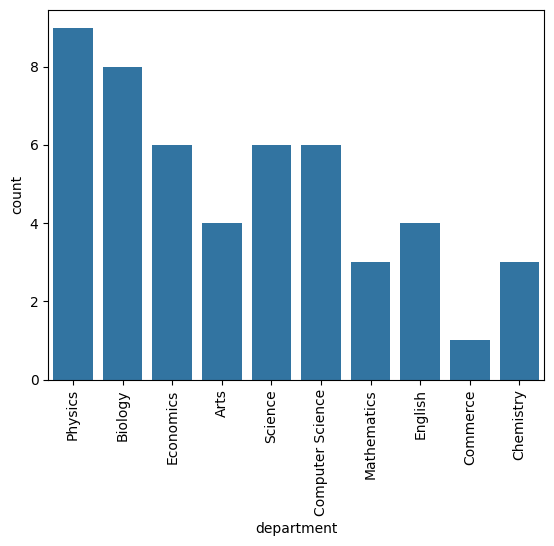

In [48]:
sns.countplot(data=student_data,x="department")
plt.xticks(rotation=90)

# Question 10: [ Marks 10 ]

create a scatter plot showing attendance vs score.

* Color the points by department
* Add a title: "Attendance vs Score by Department"
* Label X-axis as "Attendance (%)" and Y-axis as "Score"
* Display the chart

# Write Answer 10:

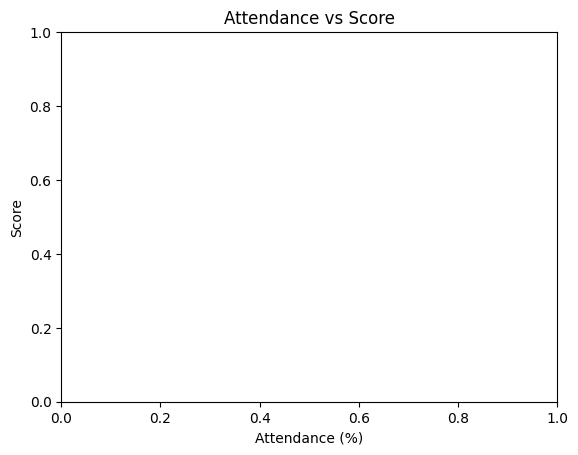

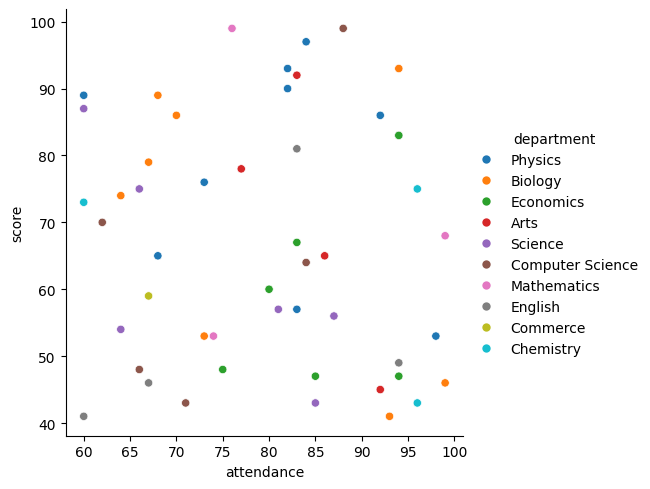

In [58]:
plt.xlabel("Attendance (%)")
plt.ylabel("Score")
plt.title("Attendance vs Score")
sns.relplot(data=student_data,x='attendance',y='score',hue='department')
